In [1]:
import json
import matplotlib.pyplot as plt

def load_data(path):
    with open(path, 'r') as f:
        data = json.load(f)
    return data
    
def extract(data):
    steps = [s["step"] for s in data["steps"]]
    buses = [s["buses"] for s in data["steps"]]
    costs = [s["cost"] / 1000 for s in data["steps"]]
    final = data["total_cost"] / 1000
    return steps, buses, costs, final

dataset_name = 'qlink_3,7,8'
rl_data_path = 'viz_data/qlink_3,7,8_2026-03-20-16:30:55.json'
rl_data = load_data(rl_data_path)
metaheuristic_path = 'viz_data/qlink_378_synthetic_baseline.json' # TODO: add the actual metaheuristic result
metaheuristic_data = load_data(metaheuristic_path)

if dataset_name == 'qlink_3,7,8':
    n_trips = 590
elif dataset_name == 'qlink_7,8':
    n_trips = 389
elif dataset_name == 'qlink_3':
    n_trips = 201
elif dataset_name == 'qlink_7':
    n_trips = 196
else:
    n_trips = 193

# Number of buses needed over CG steps

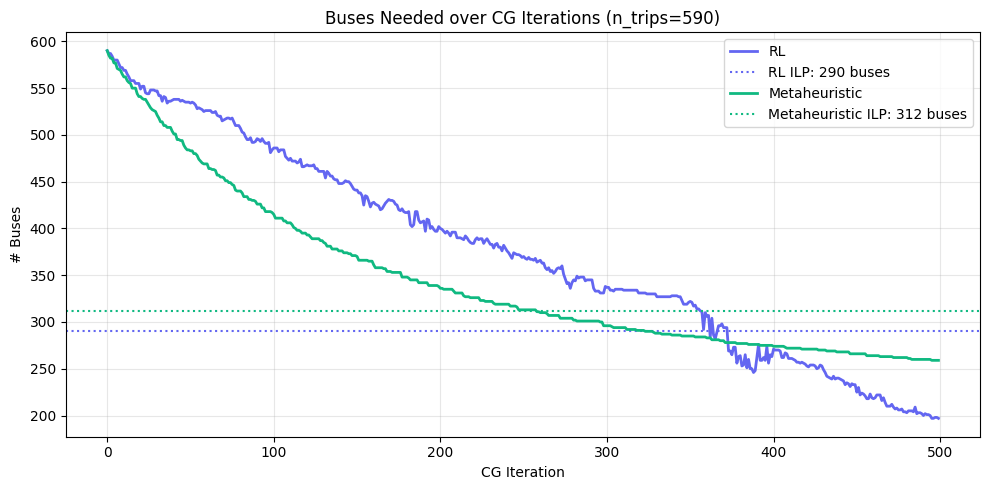

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))

rl_steps = [s["step"]  for s in rl_data["steps"]]
rl_buses = [s["buses"] for s in rl_data["steps"]]
for data, name, color in [
    (rl_data,   "RL",       "#6366f1"),
    (metaheuristic_data, "Metaheuristic", "#10b981"),
]:
    steps = [s["step"] for s in data["steps"]]
    costs = [s["buses"]  for s in data["steps"]]
    final = data["total_buses"]

    ax.plot(steps, costs, label=name, color=color, linewidth=2)
    ax.axhline(y=final, color=color, linestyle=":", linewidth=1.5,
               label=f"{name} ILP: {final:.0f} buses")

ax.set_xlabel("CG Iteration")
ax.set_ylabel("# Buses")
ax.set_title(f"Buses Needed over CG Iterations (n_trips={n_trips})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Reduced Cost over CG steps

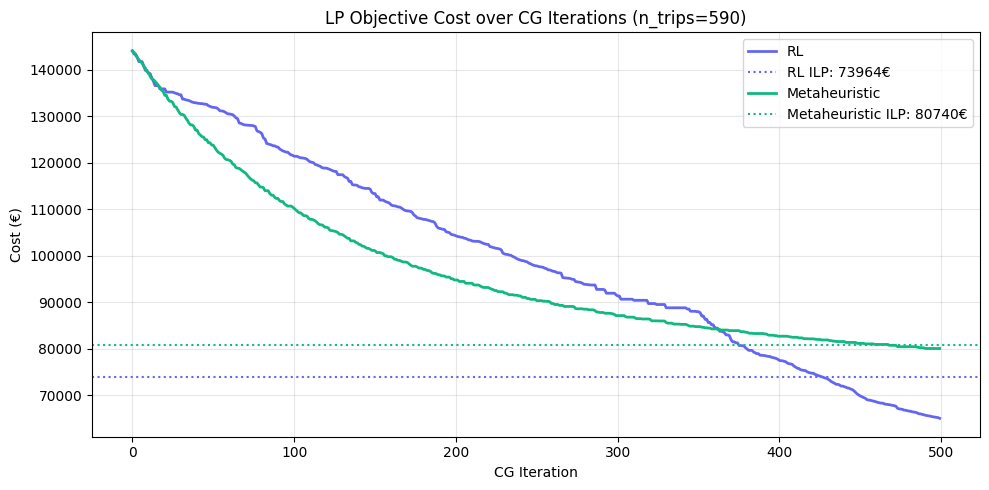

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

for data, name, color in [
    (rl_data,   "RL",       "#6366f1"),
    (metaheuristic_data, "Metaheuristic", "#10b981"),
]:
    steps = [s["step"] for s in data["steps"]]
    costs = [s["cost"]  for s in data["steps"]]
    final = data["total_cost"]

    ax.plot(steps, costs, label=name, color=color, linewidth=2)
    ax.axhline(y=final, color=color, linestyle=":", linewidth=1.5,
               label=f"{name} ILP: {final:.0f}€")

ax.set_xlabel("CG Iteration")
ax.set_ylabel("Cost (€)")
ax.set_title(f"LP Objective Cost over CG Iterations (n_trips={n_trips})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()